In [12]:
from IPython.display import HTML, display

INTRO_HTML = r'''
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

/* Kaggle-safe: avoid 100vw tricks that can clip inside the notebook output container */
.nb-hero-wrap{
  width: 100%;
  box-sizing: border-box;
  margin: 0;
}

/* Inner container */
.nb-hero{
  max-width: 1100px;
  margin: 0 auto;
  padding: 34px 22px;
}

.nb-cards{
  display: grid;
  grid-template-columns: 1fr;     /* stack (always) */
  gap: 12px;
  margin-top: 14px;
}

.nb-card{
  background: rgba(255,255,255,0.08);
  padding: 16px 16px;
  border-radius: 14px;
  border: 1px solid rgba(255,255,255,0.10);
}

@media (max-width: 640px){
  .nb-hero{ padding: 24px 14px; }
}
</style>

<div class="nb-hero-wrap" style="
  background: radial-gradient(1200px 420px at 50% 0%, rgba(102,227,255,0.14), transparent 55%),
              linear-gradient(135deg, #0b1220, #0f2a4a);
  border-radius: 18px;
  color: #e8f0ff;
  font-family: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial, sans-serif;
  border: 1px solid rgba(255,255,255,0.12);
  box-shadow: 0 14px 36px rgba(0,0,0,0.18);
  overflow: hidden;
">

  <div class="nb-hero">
    <div style="text-align:center;">
      <div style="font-size:clamp(28px, 4.2vw, 42px); font-weight:900; letter-spacing:0.2px; line-height:1.12;">
        RAG QA Evaluation Logs &amp; Corpus
      </div>
      <div style="margin-top:10px; font-size:clamp(14px, 1.6vw, 16px); color: rgba(232,240,255,0.88); line-height:1.75;">
        Quality, retrieval behavior, cost, latency — and where things go wrong.
      </div>
    </div>

    <div style="margin:18px 0 14px 0; height:1px; background: rgba(255,255,255,0.14);"></div>

    <div class="nb-cards">
      <div class="nb-card">
        <div style="font-weight:850; color:#66e3ff; margin-bottom:6px;">What you’ll do</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          Load the tables, verify joins &amp; uniqueness, review coverage, inspect failure slices, and train one baseline model
          to quantify how much signal exists in the logs.
        </div>
      </div>

      <div class="nb-card">
        <div style="font-weight:850; color:#b9a7ff; margin-bottom:6px;">What you’ll get</div>
        <div style="font-size:15px; line-height:1.85; color: rgba(232,240,255,0.92);">
          Clear tables and plots for: schema &amp; missingness, risk slices, configuration comparison,
          retrieval vs answer behavior, and confidence threshold trade-offs.
        </div>
      </div>
    </div>

    <div style="margin-top:14px; display:flex; flex-wrap:wrap; gap:10px;">
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Data</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Quality</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Slices</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Costs</span>
      <span style="padding:6px 10px; border-radius:999px; background: rgba(255,255,255,0.10);
        border:1px solid rgba(255,255,255,0.10); font-size:12px;">Confidence gate</span>
    </div>
  </div>

</div>
'''
display(HTML(INTRO_HTML))


## Notebook outline

We start with basic validation (keys/joins), then move from broad metrics to deeper slices:
coverage vs demand, failure modes (retrieval vs answer), configuration comparison, and one baseline model.

### Goals
- Confirm the dataset is internally consistent (keys and joins).
- Summarize quality, hallucination risk, cost, and latency.
- Explain where performance changes by domain, scenario, and configuration.
- Separate failures into retrieval problems vs answer-generation problems.
- Train **one** baseline model to estimate how predictable correctness is from available features.

### Expected outputs
- Clean tables: schema/missingness, risk slices, configuration summary, threshold trade-offs.
- Clear plots: distributions, heatmaps, cost–quality trade-offs, and calibration.

## System picture

```text
        ┌────────────────┐      ┌─────────────────┐      ┌────────────────────────────┐
        │   Documents    │ ───▶ │     Chunks      │ ───▶ │   Retrieval (top-k list)   │
        └────────────────┘      └─────────────────┘      └────────────────────────────┘
                 ▲                        │                            │
                 │                        ▼                            ▼
         Corpus metadata         Retrieval events             QA eval runs (labels)
                 │                        │                            │
                 ▼                        ▼                            ▼
        Scenarios & use cases ─────────────────────────▶ System-level metrics & logs
```


In [ ]:
from pathlib import Path
from typing import Dict, Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn')
warnings.filterwarnings('ignore', category=FutureWarning, module=r'seaborn\..*')
warnings.filterwarnings('ignore', category=FutureWarning, module=r'pandas')


from IPython.display import HTML, display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
from sklearn.calibration import calibration_curve

RANDOM_STATE = 42
TOP_K_CHUNKS_TO_SHOW = 5
MIN_SLICE_N = 30
MIN_SEGMENT_N = 15

RETRIEVAL_OK_THRESHOLD = 0.80
THRESHOLDS = np.linspace(0.10, 0.90, 9)

REQUIRED_FILES = ['rag_corpus_documents.csv', 'rag_corpus_chunks.csv', 'rag_qa_eval_runs.csv', 'rag_retrieval_events.csv', 'rag_qa_scenarios.csv']

def resolve_data_dir() -> Path:
    """Find the folder that contains the dataset CSV files (works on Kaggle + local runs)."""
    here = Path(".")
    if all((here / f).exists() for f in REQUIRED_FILES):
        return here

    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.iterdir():
            if p.is_dir() and all((p / f).exists() for f in REQUIRED_FILES):
                return p

        hits = list(kaggle_root.rglob(REQUIRED_FILES[2]))
        for h in hits[:25]:
            base = h.parent
            if all((base / f).exists() for f in REQUIRED_FILES):
                return base

    hits = list(here.rglob(REQUIRED_FILES[2]))
    for h in hits[:25]:
        base = h.parent
        if all((base / f).exists() for f in REQUIRED_FILES):
            return base

    raise FileNotFoundError(
        "Could not locate dataset CSVs. Place them next to the notebook, "
        "or ensure they exist under /kaggle/input/<dataset>/."
    )

DATA_DIR = resolve_data_dir()
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

NOTEBOOK_CSS = r"""
<style>
@import url('https://fonts.googleapis.com/css2?family=Inter:wght@400;600;700;900&display=swap');

:root{
  --bg0:#0b1220;
  --bg1:#0f2a4a;
  --stroke:rgba(255,255,255,0.12);
  --text:#e8f0ff;
  --muted:rgba(232,240,255,0.84);
  --accent:#66e3ff;
  --good:#38bdf8;
  --warn:#fbbf24;
  --bad:#fb7185;
  --font: Inter, ui-sans-serif, system-ui, -apple-system, Segoe UI, Roboto, Arial;
}

/* Slightly larger default markdown rendering */
.rendered_html, .jp-RenderedHTMLCommon{
  font-size: 16px;
  line-height: 1.65;
}

/* Section banner */
.nb-section{
  margin:22px 0 14px 0;
  padding:16px 18px;
  border-left: 6px solid var(--accent);
  background: linear-gradient(90deg, rgba(102,227,255,0.16), rgba(255,255,255,0.02));
  border-radius: 16px;
  font-family: var(--font);
}
.nb-section h2{ margin:0; font-size:26px; font-weight:900; color:var(--text); letter-spacing:0.2px; }
.nb-section p{ margin:8px 0 0 0; color:var(--muted); line-height:1.8; font-size:16px; }

/* Callouts */
.nb-call{
  margin:16px 0;
  padding:16px 18px;
  border-radius:16px;
  font-family:var(--font);
  border:1px solid rgba(255,255,255,0.12);
  background: rgba(255,255,255,0.06);
}
.nb-call.good{ border-left:6px solid var(--good); }
.nb-call.warn{ border-left:6px solid var(--warn); }
.nb-call.bad{  border-left:6px solid var(--bad);  }
.nb-call .t{ font-weight:900; color:var(--text); margin-bottom:8px; font-size:18px; }
.nb-call .d{ color:var(--muted); line-height:1.8; font-size:16px; }

/* KPI cards */
.nb-kpis{
  display:grid;
  grid-template-columns: repeat(4, minmax(0, 1fr));
  gap:14px;
  margin:14px 0 6px 0;
}
.nb-kpi{
  background:rgba(255,255,255,0.08);
  border:1px solid rgba(255,255,255,0.10);
  border-radius:16px;
  padding:14px 14px;
  font-family:var(--font);
}
.nb-kpi .k{ font-size:14px; color:var(--muted); margin-bottom:8px; }
.nb-kpi .v{ font-size:24px; font-weight:900; color:var(--text); line-height:1.1; }
.nb-kpi .s{ font-size:14px; color:var(--muted); margin-top:6px; line-height:1.4; }

@media (max-width: 980px){
  .nb-kpis{ grid-template-columns: repeat(2, minmax(0,1fr)); }
}

/* Tables */
table.dataframe{ font-size:15px; }

/* Make code + outputs more readable */
div.output_area pre, .jp-OutputArea pre, .output pre{
  font-size: 14px !important;
  line-height: 1.55 !important;
}
.CodeMirror pre, .jp-CodeMirrorEditor .cm-content{
  font-size: 14px !important;
  line-height: 1.6 !important;
}

</style>
"""
display(HTML(NOTEBOOK_CSS))


def section(title: str, desc: str) -> None:
    display(HTML(f"""
    <div class="nb-section">
      <h2>{title}</h2>
      <p>{desc}</p>
    </div>
    """))


def callout(kind: str, title: str, desc: str) -> None:
    kind = kind if kind in {"good","warn","bad"} else "good"
    display(HTML(f"""
    <div class="nb-call {kind}">
      <div class="t">{title}</div>
      <div class="d">{desc}</div>
    </div>
    """))


def kpi_row(items) -> None:
    cards = ""
    for it in items:
        if isinstance(it, dict):
            k, v, s = it.get("k",""), it.get("v",""), it.get("s","")
        else:
            k, v, s = it
        cards += f"""
        <div class="nb-kpi">
          <div class="k">{k}</div>
          <div class="v">{v}</div>
          <div class="s">{s}</div>
        </div>
        """
    display(HTML(f"<div class='nb-kpis'>{cards}</div>"))


def style_table(
    df: pd.DataFrame,
    max_rows: int = 30,
    center_cols=None,
    wrap_cols=None,
    max_width_px=None,
):
    center_cols = set(center_cols or [])
    wrap_cols = set(wrap_cols or [])
    max_width_px = dict(max_width_px or {})

    view = df.head(max_rows).copy()

    for c in view.columns:
        lc = str(c).lower()

        if any(k in lc for k in ["query", "answer", "title", "snippet", "text"]):
            wrap_cols.add(c)
            if c not in max_width_px:
                if "title" in lc:
                    center_cols.add(c)
                    max_width_px[c] = 300
                elif "snippet" in lc:
                    max_width_px[c] = 600
                else:
                    max_width_px[c] = 680

        if any(k in lc for k in ["id", "rank", "n_", "rate", "score", "cost", "latency", "pct", "fraction", "prob", "tokens", "index"]):
            center_cols.add(c)

        if c not in wrap_cols:
            dt = str(view[c].dtype)
            if dt.startswith(("int", "float", "bool")):
                center_cols.add(c)

    st = (
        view.style
        .hide(axis="index")
        .set_table_styles(
            [
                {"selector": "table", "props": [
                    ("border-collapse", "separate"),
                    ("border-spacing", "0"),
                    ("border-radius", "16px"),
                    ("overflow", "hidden"),
                    ("border", "1px solid rgba(255,255,255,0.12)"),
                    ("background", "rgba(11,18,32,0.70)"),
                    ("box-shadow", "0 12px 28px rgba(0,0,0,0.25)"),
                ]},
                {"selector": "thead th", "props": [
                    ("background", "rgba(11,18,32,0.92)"),
                    ("color", "rgba(232,240,255,0.98)"),
                    ("font-weight", "900"),
                    ("text-align", "center"),
                    ("border-bottom", "1px solid rgba(255,255,255,0.14)"),
                    ("padding", "12px 12px"),
                    ("white-space", "nowrap"),
                ]},
                {"selector": "tbody td", "props": [
                    ("color", "rgba(232,240,255,0.92)"),
                    ("border-bottom", "1px solid rgba(255,255,255,0.10)"),
                    ("padding", "12px 12px"),
                    ("vertical-align", "top"),
                    ("line-height", "1.55"),
                    ("font-size", "15px"),
                ]},
                {"selector": "tbody tr:nth-child(even) td", "props": [
                    ("background", "rgba(255,255,255,0.03)"),
                ]},
                {"selector": "tbody tr:hover td", "props": [
                    ("background", "rgba(102,227,255,0.08)"),
                ]},
            ],
            overwrite=False,
        )
    )

    cols_center = [c for c in center_cols if c in view.columns]
    if cols_center:
        st = st.set_properties(subset=cols_center, **{"text-align": "center"})

    cols_wrap = [c for c in wrap_cols if c in view.columns]
    if cols_wrap:
        st = st.set_properties(subset=cols_wrap, **{"white-space": "normal", "word-break": "break-word"})

    for col, w in max_width_px.items():
        if col in view.columns:
            st = st.set_properties(subset=[col], **{"max-width": f"{int(w)}px"})

    return st


def apply_plot_theme() -> None:
    sns.set_theme(style="whitegrid", context="notebook")
    plt.rcParams["figure.figsize"] = (9.5, 5.2)
    plt.rcParams["axes.titlesize"] = 14
    plt.rcParams["axes.labelsize"] = 12
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["grid.alpha"] = 0.25
    plt.rcParams["font.size"] = 12.5

apply_plot_theme()


def load_csv(name: str, data_dir: Path = DATA_DIR) -> pd.DataFrame:
    path = data_dir / name
    if not path.exists():
        raise FileNotFoundError(f"Expected file not found: {path}")
    df = pd.read_csv(path)
    print(f"Loaded {name} with shape {df.shape}")
    return df


def compact_info(df: pd.DataFrame, name: str) -> pd.DataFrame:
    out = pd.DataFrame({
        "column": df.columns,
        "dtype": [str(t) for t in df.dtypes],
        "nulls": df.isna().sum().values,
        "null_rate": (df.isna().mean().values).round(4),
    }).sort_values("null_rate", ascending=False).reset_index(drop=True)
    out.insert(0, "table", name)
    return out


def value_counts_with_pct(df: pd.DataFrame, col: str) -> pd.DataFrame:
    vc = df[col].value_counts(dropna=False)
    pct = df[col].value_counts(normalize=True, dropna=False)
    return pd.DataFrame({"count": vc, "pct": pct}).sort_values("count", ascending=False)


def assert_all_values_in(left: pd.Series, right: pd.Series, name: str) -> None:
    missing = set(pd.Series(left).dropna().unique()) - set(pd.Series(right).dropna().unique())
    if missing:
        example_values = list(missing)[:5]
        raise ValueError(f"{name}: found {len(missing)} missing keys, e.g. {example_values}")
    print(f"[OK] {name} — all keys are consistent.")


def safe_quantile(x: pd.Series, q: float) -> float:
    x = pd.to_numeric(x, errors="coerce").dropna()
    return float(x.quantile(q)) if len(x) else float("nan")


def clip_text(s: str, n: int = 220) -> str:
    if not isinstance(s, str):
        s = "" if pd.isna(s) else str(s)
    s = " ".join(s.split())
    return (s[:n] + "…") if len(s) > n else s


def ensure_numeric_flag_keep_nan(df: pd.DataFrame, col: str) -> None:
    """Coerce a 0/1-ish label column to numeric while *preserving NaNs*.
    This prevents silently treating missing labels as negatives.
    """
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")


def ensure_int_flag_fillna(df: pd.DataFrame, col: str, fill_value: int = 0) -> None:
    """Coerce a flag to int, filling NaNs (use sparingly; not for ground-truth labels)."""
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(fill_value).astype(int)


def assert_unique(df: pd.DataFrame, key: str, name: str) -> None:
    """Fail fast if a supposed primary key is not unique."""
    if key in df.columns:
        dups = int(df[key].duplicated().sum())
        if dups:
            raise ValueError(f"{name}: '{key}' has {dups} duplicate values.")
        print(f"[OK] {name} — '{key}' is unique.")
def build_kpi_snapshot(eval_runs: pd.DataFrame) -> pd.DataFrame:
    """High-level KPIs with label coverage (so missing labels don't lie to you)."""
    out: Dict[str, float] = {}
    out["n_eval_runs"] = float(len(eval_runs))

    # Correctness
    if "is_correct" in eval_runs.columns:
        s = pd.to_numeric(eval_runs["is_correct"], errors="coerce")
        out["correct_label_coverage"] = float(s.notna().mean())
        out["n_correct_labeled"] = float(s.notna().sum())
        out["correct_rate"] = float(s.mean())  # mean skips NaN by default

    # Hallucination
    if "hallucination_flag" in eval_runs.columns:
        h = pd.to_numeric(eval_runs["hallucination_flag"], errors="coerce")
        out["hallucination_label_coverage"] = float(h.notna().mean())
        out["n_hallucination_labeled"] = float(h.notna().sum())
        out["hallucination_rate"] = float(h.mean())

    # Cost & latency
    if "total_cost_usd" in eval_runs.columns:
        out["avg_cost_usd"] = float(pd.to_numeric(eval_runs["total_cost_usd"], errors="coerce").mean())
        out["p95_cost_usd"] = float(safe_quantile(eval_runs["total_cost_usd"], 0.95))
    if "total_latency_ms" in eval_runs.columns:
        out["avg_latency_ms"] = float(pd.to_numeric(eval_runs["total_latency_ms"], errors="coerce").mean())
        out["p95_latency_ms"] = float(safe_quantile(eval_runs["total_latency_ms"], 0.95))

    # Retrieval metrics
    if {"recall_at_10", "mrr_at_10"}.issubset(eval_runs.columns):
        out["avg_recall_at_10"] = float(pd.to_numeric(eval_runs["recall_at_10"], errors="coerce").mean())
        out["avg_mrr_at_10"] = float(pd.to_numeric(eval_runs["mrr_at_10"], errors="coerce").mean())

    kpi = pd.DataFrame([{k: v for k, v in out.items()}]).T.reset_index()
    kpi.columns = ["metric", "value"]
    return kpi

def summarize_group(
    df: pd.DataFrame,
    group_cols: list[str],
    target_col: str = "is_correct",
    hall_col: str = "hallucination_flag",
) -> pd.DataFrame:
    """Group-level summary with *explicit label coverage*.

    - n_rows: total rows in the slice
    - n_labeled_correct: number of non-NaN correctness labels
    - correct_rate: mean correctness on labeled rows
    - n_labeled_hallucination / hallucination_rate likewise (if available)
    """
    count_col = "example_id" if "example_id" in df.columns else ("run_id" if "run_id" in df.columns else group_cols[0])

    aggs: Dict[str, tuple] = {}
    aggs["n_rows"] = (count_col, "size")

    if target_col in df.columns:
        aggs["n_labeled_correct"] = (target_col, lambda s: pd.to_numeric(pd.Series(s), errors="coerce").notna().sum())
        aggs["correct_rate"] = (target_col, lambda s: float(pd.to_numeric(pd.Series(s), errors="coerce").mean()))
    if hall_col in df.columns:
        aggs["n_labeled_hallucination"] = (hall_col, lambda s: pd.to_numeric(pd.Series(s), errors="coerce").notna().sum())
        aggs["hallucination_rate"] = (hall_col, lambda s: float(pd.to_numeric(pd.Series(s), errors="coerce").mean()))

    if "total_latency_ms" in df.columns:
        aggs["avg_latency_ms"] = ("total_latency_ms", lambda s: float(pd.to_numeric(pd.Series(s), errors="coerce").mean()))
        aggs["p95_latency_ms"] = ("total_latency_ms", lambda s: safe_quantile(pd.Series(s), 0.95))

    if "total_cost_usd" in df.columns:
        aggs["avg_cost_usd"] = ("total_cost_usd", lambda s: float(pd.to_numeric(pd.Series(s), errors="coerce").mean()))
        aggs["p95_cost_usd"] = ("total_cost_usd", lambda s: safe_quantile(pd.Series(s), 0.95))

    return df.groupby(group_cols, dropna=False).agg(**aggs).reset_index()


def pareto_frontier(df: pd.DataFrame, x_col: str, y_col: str) -> pd.DataFrame:
    tmp = df[[x_col, y_col]].dropna().sort_values(x_col).copy()
    best_y = -np.inf
    keep = []
    for idx, row in tmp.iterrows():
        yv = float(row[y_col])
        if yv > best_y:
            keep.append(idx)
            best_y = yv
    return df.loc[keep].copy()


print(f"Using DATA_DIR = {DATA_DIR.resolve()}")

Using DATA_DIR = D:\Work\Work\AI Courses\Downloads\Week 0\2RAG Dataset\Kaggle\data


In [14]:
section("Load data", "Load all tables and build a quick summary of shapes.")

docs = load_csv("rag_corpus_documents.csv")
chunks = load_csv("rag_corpus_chunks.csv")
eval_runs = load_csv("rag_qa_eval_runs.csv")
retrieval = load_csv("rag_retrieval_events.csv")
scenarios = load_csv("rag_qa_scenarios.csv")

tables = {
    "documents": docs,
    "chunks": chunks,
    "eval_runs": eval_runs,
    "retrieval_events": retrieval,
    "scenarios": scenarios,
}

table_summary = pd.DataFrame({
    "table": list(tables.keys()),
    "n_rows": [len(df) for df in tables.values()],
    "n_cols": [df.shape[1] for df in tables.values()],
}).sort_values("table").reset_index(drop=True)

display(style_table(table_summary, max_rows=10, center_cols=["table","n_rows","n_cols"]))


Loaded rag_corpus_documents.csv with shape (658, 19)
Loaded rag_corpus_chunks.csv with shape (5237, 6)
Loaded rag_qa_eval_runs.csv with shape (3824, 46)
Loaded rag_retrieval_events.csv with shape (93375, 9)
Loaded rag_qa_scenarios.csv with shape (88, 11)


table,n_rows,n_cols
chunks,5237,6
documents,658,19
eval_runs,3824,46
retrieval_events,93375,9
scenarios,88,11


In [ ]:
section("Integrity checks", "Verify that joins are safe before slicing or comparing results.")

assert_unique(docs, "doc_id", "docs")
assert_unique(chunks, "chunk_id", "chunks")
assert_unique(eval_runs, "run_id", "eval_runs")
assert_unique(scenarios, "scenario_id", "scenarios")


if {"doc_id"}.issubset(docs.columns) and {"doc_id"}.issubset(chunks.columns):
    assert_all_values_in(chunks["doc_id"], docs["doc_id"], "chunks.doc_id -> docs.doc_id")

if {"chunk_id"}.issubset(chunks.columns) and {"chunk_id"}.issubset(retrieval.columns):
    assert_all_values_in(retrieval["chunk_id"], chunks["chunk_id"], "retrieval.chunk_id -> chunks.chunk_id")

if {"run_id"}.issubset(eval_runs.columns) and {"run_id"}.issubset(retrieval.columns):
    assert_all_values_in(retrieval["run_id"], eval_runs["run_id"], "retrieval.run_id -> eval_runs.run_id")

if {"example_id"}.issubset(eval_runs.columns) and {"example_id"}.issubset(retrieval.columns):
    assert_all_values_in(retrieval["example_id"], eval_runs["example_id"], "retrieval.example_id -> eval_runs.example_id")

if {"scenario_id"}.issubset(scenarios.columns) and {"scenario_id"}.issubset(eval_runs.columns):
    assert_all_values_in(eval_runs["scenario_id"], scenarios["scenario_id"], "eval_runs.scenario_id -> scenarios.scenario_id")

callout(
    "good",
    "Result",
    "If these checks pass, slice tables (scenario breakdown, configuration comparison) are built on consistent keys."
)

[OK] docs — 'doc_id' is unique.
[OK] chunks — 'chunk_id' is unique.
[OK] eval_runs — 'run_id' is unique.
[OK] scenarios — 'scenario_id' is unique.
[OK] chunks.doc_id -> docs.doc_id — all keys are consistent.
[OK] retrieval.chunk_id -> chunks.chunk_id — all keys are consistent.
[OK] retrieval.run_id -> eval_runs.run_id — all keys are consistent.
[OK] retrieval.example_id -> eval_runs.example_id — all keys are consistent.
[OK] eval_runs.scenario_id -> scenarios.scenario_id — all keys are consistent.


In [16]:
section("Schema snapshot", "Dtypes + missingness, optimized for quick scanning.")

schema_view = pd.concat([compact_info(df, name) for name, df in tables.items()], ignore_index=True)
display(style_table(schema_view, max_rows=28))

callout(
    "good",
    "Note",
    "Missingness and dtype drift are common causes of confusing analysis. This table catches them early."
)


table,column,dtype,nulls,null_rate
documents,doc_id,object,0,0.000000
documents,domain,object,0,0.000000
documents,title,object,0,0.000000
documents,source_type,object,0,0.000000
documents,language,object,0,0.000000
documents,n_sections,int64,0,0.000000
documents,n_tokens,int64,0,0.000000
documents,n_chunks,int64,0,0.000000
documents,avg_chunk_tokens,float64,0,0.000000
documents,created_at_utc,object,0,0.000000


In [ ]:
section("KPI snapshot", "High-level rates and tail metrics (p95) for latency and cost.")

eval_runs = eval_runs.copy()
ensure_numeric_flag_keep_nan(eval_runs, "is_correct")
ensure_numeric_flag_keep_nan(eval_runs, "hallucination_flag")

kpi = build_kpi_snapshot(eval_runs)
display(style_table(kpi, max_rows=20))

kpi_map = dict(zip(kpi["metric"], kpi["value"]))

cov = float(kpi_map.get("correct_label_coverage", 1.0)) if "correct_label_coverage" in kpi_map else 1.0
if cov < 0.98:
    callout("warn", "Label coverage", f"Correctness labels are only {cov:.1%} covered. Rates below are computed on labeled rows only.")


kpi_row([
    {"k":"Correct rate", "v": f"{kpi_map.get('correct_rate', np.nan):.3f}" if "correct_rate" in kpi_map else "—", "s":"Higher is better"},
    {"k":"Hallucination rate", "v": f"{kpi_map.get('hallucination_rate', np.nan):.3f}" if "hallucination_rate" in kpi_map else "—", "s":"Lower is safer"},
    {"k":"Avg cost (USD)", "v": f"{kpi_map.get('avg_cost_usd', np.nan):.4f}" if "avg_cost_usd" in kpi_map else "—", "s":"Budget pressure"},
    {"k":"p95 latency (ms)", "v": f"{kpi_map.get('p95_latency_ms', np.nan):.0f}" if "p95_latency_ms" in kpi_map else "—", "s":"Tail latency matters"},
])

eval_labeled = eval_runs.copy()
ensure_numeric_flag_keep_nan(eval_labeled, "is_correct")
ensure_numeric_flag_keep_nan(eval_labeled, "hallucination_flag")
if "is_correct" in eval_labeled.columns:
    eval_labeled = eval_labeled.dropna(subset=["is_correct"]).copy()


metric,value
n_eval_runs,3824.000000
correct_label_coverage,1.000000
n_correct_labeled,3824.000000
correct_rate,0.743985
hallucination_label_coverage,1.000000
n_hallucination_labeled,3824.000000
hallucination_rate,0.190115
avg_cost_usd,0.000986
p95_cost_usd,0.004360
avg_latency_ms,948.618724


domain,docs_fraction,eval_runs_fraction
financial_reports,0.132219,0.201621
developer_docs,0.112462,0.192730
hr_policies,0.118541,0.156381
medical_guides,0.118541,0.123169
product_docs,0.127660,0.094665
policies,0.109422,0.090481
support_faq,0.142857,0.071914
research_papers,0.126140,0.069038


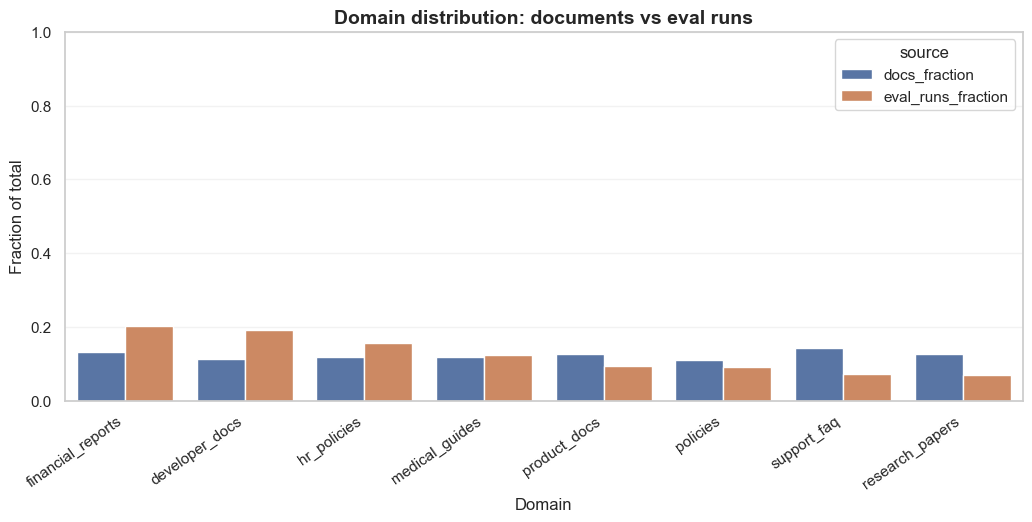

In [18]:
section("Corpus vs questions", "Compare indexed content vs the question mix in evaluation runs.")

if "domain" in docs.columns and "domain" in eval_runs.columns:
    doc_domain = docs["domain"].value_counts(normalize=True).rename("docs_fraction")
    run_domain = eval_runs["domain"].value_counts(normalize=True).rename("eval_runs_fraction")
    dom_compare = pd.concat([doc_domain, run_domain], axis=1).fillna(0).reset_index().rename(columns={"index":"domain"})
    dom_plot = dom_compare[dom_compare["eval_runs_fraction"] > 0].sort_values("eval_runs_fraction", ascending=False)

    display(style_table(dom_plot, max_rows=25))

    dom_melt = dom_plot.melt(
        id_vars="domain",
        value_vars=["docs_fraction", "eval_runs_fraction"],
        var_name="source",
        value_name="fraction",
    )

    plt.figure(figsize=(10.5, 5.4))
    sns.barplot(data=dom_melt, x="domain", y="fraction", hue="source")
    plt.xticks(rotation=35, ha="right")
    plt.ylabel("Fraction of total")
    plt.xlabel("Domain")
    plt.title("Domain distribution: documents vs eval runs")
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

    callout(
        "warn",
        "Reading this",
        "High eval traffic with low corpus coverage often indicates where the index needs expansion or stricter retrieval controls."
    )
else:
    callout("warn", "Coverage vs demand", "Column 'domain' missing in docs and/or eval_runs.")


difficulty,scenario_type,n_scenarios
easy,no_answer_probe,2
easy,account_update,1
easy,benefit_lookup,1
easy,data_freshness,1
easy,documentation_lookup,1
easy,environment_capability,1
easy,environment_usage,1
easy,financial_analysis,1
easy,governance,1
easy,kpi_lookup,1


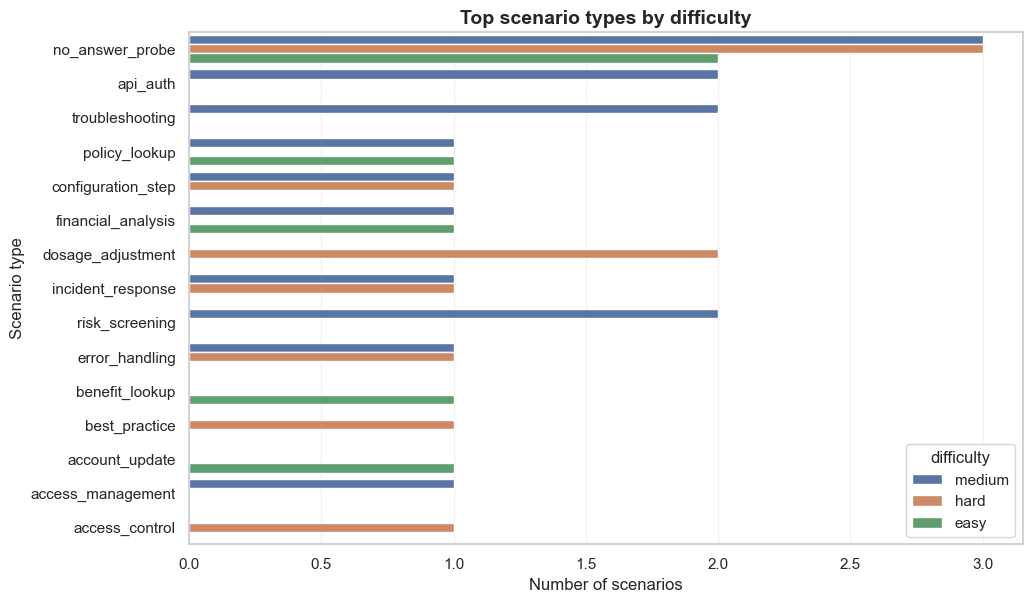

In [19]:
section("Scenario landscape", "Understand the mix of scenario types and difficulty.")

scenarios_ = scenarios.copy()
if "difficulty_level" in scenarios_.columns and "difficulty" not in scenarios_.columns:
    scenarios_ = scenarios_.rename(columns={"difficulty_level": "difficulty"})

if {"difficulty", "scenario_type"}.issubset(scenarios_.columns):
    scen_summary = (
        scenarios_
        .groupby(["difficulty", "scenario_type"])["scenario_id"]
        .count()
        .rename("n_scenarios")
        .reset_index()
        .sort_values(["difficulty", "n_scenarios"], ascending=[True, False])
    )
    display(style_table(scen_summary, max_rows=25))

    plt.figure(figsize=(10.5, 6.2))
    top_types = (
        scen_summary.groupby("scenario_type")["n_scenarios"].sum()
        .sort_values(ascending=False)
        .head(15)
        .index
    )
    sns.countplot(
        data=scenarios_[scenarios_["scenario_type"].isin(top_types)],
        y="scenario_type",
        hue="difficulty",
        order=top_types,
    )
    plt.xlabel("Number of scenarios")
    plt.ylabel("Scenario type")
    plt.title("Top scenario types by difficulty")
    plt.tight_layout()
    plt.show()
else:
    callout("warn", "Scenario landscape", "Columns 'difficulty' and/or 'scenario_type' not present in scenarios.")


In [20]:
section("Example drill-downs", "Follow individual runs: query → retrieved chunks → outcome labels.")

def pick_example(eval_df: pd.DataFrame, correct: Optional[bool] = None, hallucinated: Optional[bool] = None) -> pd.Series:
    df = eval_df.copy()
    if correct is not None and "is_correct" in df.columns:
        df = df[df["is_correct"] == int(correct)]
    if hallucinated is not None and "hallucination_flag" in df.columns:
        df = df[df["hallucination_flag"] == int(hallucinated)]
    if df.empty:
        df = eval_df
    return df.sample(1, random_state=RANDOM_STATE).iloc[0]


def show_example_story(row: pd.Series) -> None:
    run_id = row.get("run_id")

    cols_main = [c for c in ["example_id","run_id","domain","task_type","difficulty","scenario_id","query","gold_answer"] if c in eval_runs.columns]
    optional = [c for c in [
        "correctness_label","is_correct","faithfulness_label","hallucination_flag",
        "recall_at_10","mrr_at_10","total_latency_ms","total_cost_usd",
        "retrieval_strategy","generator_model"
    ] if c in eval_runs.columns]
    cols_show = cols_main + optional

    display(style_table(
        eval_runs.loc[eval_runs["run_id"] == run_id, cols_show].head(1),
        max_rows=1,
        wrap_cols=["query","gold_answer"],
        max_width_px={"query": 680, "gold_answer": 680},
    ))

    if run_id is None or "run_id" not in retrieval.columns:
        callout("warn", "Retrieval logs", "No retrieval logs available for this run.")
        return

    subset = retrieval[retrieval["run_id"] == run_id].copy()

    if "rank" in subset.columns:
        subset = subset.sort_values("rank", ascending=True)
    elif "retrieval_score" in subset.columns:
        subset = subset.sort_values("retrieval_score", ascending=False)
    elif "score" in subset.columns:
        subset = subset.sort_values("score", ascending=False)
    subset = subset.head(TOP_K_CHUNKS_TO_SHOW)

    if "chunk_id" in subset.columns and "chunk_id" in chunks.columns:
        subset = subset.merge(chunks, on="chunk_id", how="left", suffixes=("", "_chunk"))
    if "doc_id" in subset.columns and "doc_id" in docs.columns:
        doc_cols = ["doc_id"] + [c for c in ["title", "domain"] if c in docs.columns]
        subset = subset.merge(docs[doc_cols], on="doc_id", how="left")

    if "chunk_text" in subset.columns:
        subset["chunk_snippet"] = subset["chunk_text"].apply(lambda x: clip_text(x, 260))

    cols_to_show = [c for c in ["rank","chunk_id","is_relevant","retrieval_score","title","chunk_index","estimated_tokens","chunk_snippet"] if c in subset.columns]
    display(style_table(
        subset[cols_to_show],
        max_rows=TOP_K_CHUNKS_TO_SHOW,
        center_cols=[c for c in ["rank","chunk_id","is_relevant","retrieval_score","chunk_index","estimated_tokens"] if c in cols_to_show],
        wrap_cols=["chunk_snippet"],
        max_width_px={"chunk_snippet": 640},
    ))


row_success = pick_example(eval_runs, correct=True, hallucinated=False)
callout("good", "Example: likely correct", "One run sampled from the correct subset (and low hallucination where available).")
show_example_story(row_success)

row_risky = pick_example(eval_runs, correct=False, hallucinated=True)
callout("bad", "Example: likely risky", "One run sampled from incorrect + hallucinated subset (where available).")
show_example_story(row_risky)

example_id,run_id,domain,task_type,difficulty,scenario_id,query,gold_answer,correctness_label,is_correct,faithfulness_label,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd,retrieval_strategy,generator_model
QA002259,run_2258,support_faq,summarization,medium,SC016,Where can I check the status of my support ticket?,Ticket status is available on the support portal under 'My Requests'.,correct,1,faithful,False,1.000000,1.000000,794,0.000091,bm25,llama-3.1-8b-instruct


rank,chunk_id,is_relevant,retrieval_score,title,chunk_index,estimated_tokens,chunk_snippet
1,C01014,1,0.758587,Support playbook: handling issue and reset tickets (2020),19,93,Below are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Support playbook: handling issue and reset tickets (2020)' explains how to issue when users face reset issues. It walks through the steps that agents follow in the internal he…
2,C00084,1,0.766625,"Issue and Reset support guide (EMEA, 2019)",7,92,"Here are a few paragraphs from a practical troubleshooting FAQ. In this section of 'Issue and Reset support guide (EMEA, 2019)' explains how to ticket when users face troubleshooting issues. It walks through the steps that agents follow in the internal help ce…"
3,C00104,1,0.651113,"Troubleshooting and Issue support guide (AMER, 2019)",2,91,"Here are a few paragraphs from a practical troubleshooting FAQ. This part of 'Troubleshooting and Issue support guide (AMER, 2019)' explains how to troubleshooting when users face steps issues. It walks through the steps that agents follow in the internal help…"
4,C04901,0,0.392249,"How to ticket — internal support article (Global, 2021)",11,95,"This excerpt gathers a few paragraphs from a practical troubleshooting FAQ. In this section of 'How to ticket — internal support article (Global, 2021)' explains how to issue when users face ticket issues. It walks through the steps that agents follow in the i…"
5,C01119,1,0.564585,"How to reset — internal support article (APAC, 2019)",0,96,"Here is a mid-section excerpt from a customer support knowledge base article. This opening section of 'How to reset — internal support article (APAC, 2019)' explains how to ticket when users face steps issues. It walks through the steps that agents follow in t…"


example_id,run_id,domain,task_type,difficulty,scenario_id,query,gold_answer,correctness_label,is_correct,faithfulness_label,hallucination_flag,recall_at_10,mrr_at_10,total_latency_ms,total_cost_usd,retrieval_strategy,generator_model
QA002098,run_2097,developer_docs,comparison,hard,SC028,How do I authenticate using API keys?,API keys are passed as a bearer token in the Authorization header.,incorrect,0,unfaithful,True,1.000000,0.166667,627,0.000141,dense_then_rerank,llama-3.1-70b-instruct


rank,chunk_id,is_relevant,retrieval_score,title,chunk_index,estimated_tokens,chunk_snippet
1,C03290,0,0.339959,Service-to-service auth and endpoint — engineering guide 2024,8,83,"This portion is taken from developer documentation used by engineering teams. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns,…"
2,C03234,0,0.446808,Developer integration guide — Request and Api,2,80,"This passage comes from developer documentation used by engineering teams. This part of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response sha…"
3,C03256,0,0.757425,Developer integration guide — Request and Api,24,82,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Developer integration guide — Request and Api' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, request and response s…"
4,C03295,0,0.784004,Service-to-service auth and endpoint — engineering guide 2024,13,83,"This chunk contains part of a developer-facing guide or API reference. In this section of 'Service-to-service auth and endpoint — engineering guide 2024' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns, reques…"
5,C04775,0,0.334509,Developer integration guide — Endpoint and Response,0,82,The following section comes from developer documentation used by engineering teams. This opening section of 'Developer integration guide — Endpoint and Response' focuses on how engineering teams use the API in day‑to‑day work. It covers authentication patterns…


is_correct,count,pct
1,2845,0.743985
0,979,0.256015


correctness_label,count,pct
correct,2845,0.743985
incorrect,669,0.174948
partial,310,0.081067


faithfulness_label,count,pct
faithful,2638,0.689854
unfaithful,719,0.188023
unknown,467,0.122123


hallucination_flag,count,pct
False,3097,0.809885
True,727,0.190115


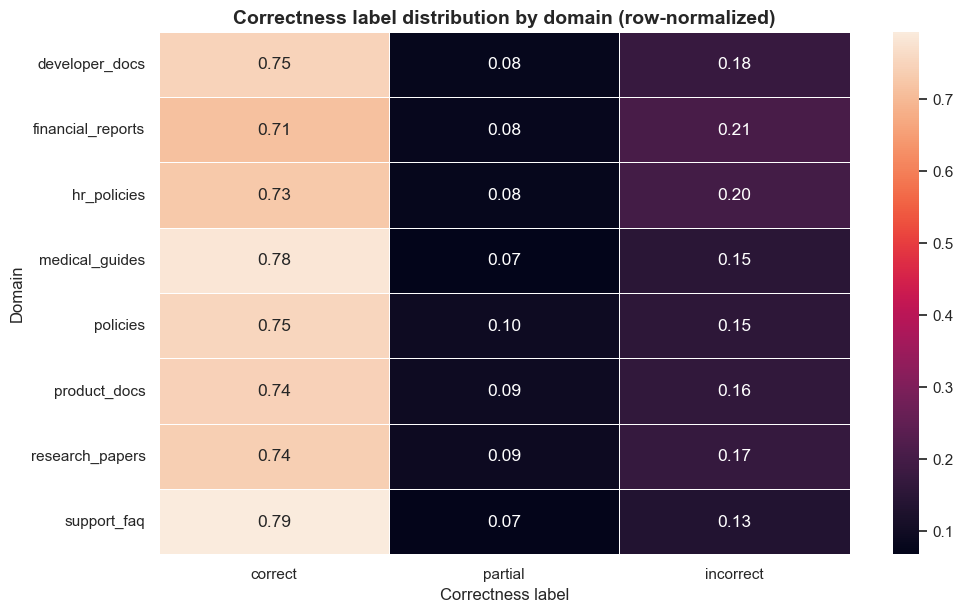

domain,hallucination_rate
hr_policies,0.214047
financial_reports,0.208820
product_docs,0.198895
research_papers,0.193182
medical_guides,0.191083
policies,0.173410
developer_docs,0.170963
support_faq,0.141818


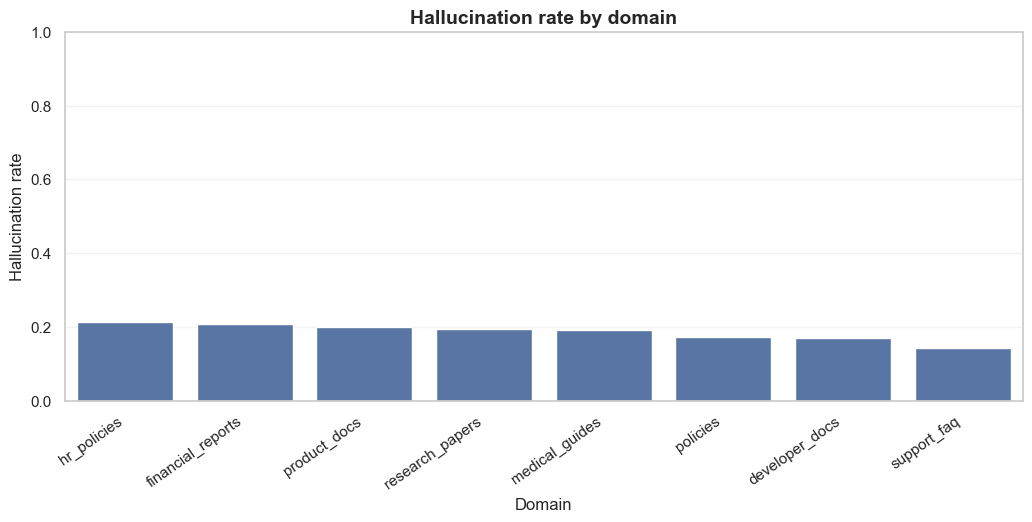

is_correct,hallucination=0,hallucination=1
is_correct=0,0.120031,0.135983
is_correct=1,0.689854,0.054132


In [ ]:
section("Label distributions", "Base rates for correctness and hallucination-related labels (with safe numeric coercion).")

label_cols = ["is_correct", "correctness_label", "faithfulness_label", "hallucination_flag"]
for col in label_cols:
    if col in eval_runs.columns:
        out = value_counts_with_pct(eval_runs, col).reset_index().rename(columns={"index": col})
        display(style_table(out, max_rows=20, center_cols=[col, "count", "pct"]))

if {"correctness_label", "domain"}.issubset(eval_runs.columns):
    ct = pd.crosstab(eval_runs["domain"], eval_runs["correctness_label"], normalize="index")
    ordered = [c for c in ["correct", "partial", "incorrect"] if c in ct.columns]
    ct_plot = ct[ordered] if ordered else ct

    plt.figure(figsize=(10.5, 6.3))
    sns.heatmap(ct_plot, annot=True, fmt=".2f", linewidths=0.5)
    plt.title("Correctness label distribution by domain (row-normalized)")
    plt.ylabel("Domain")
    plt.xlabel("Correctness label")
    plt.tight_layout()
    plt.show()

if {"hallucination_flag", "domain"}.issubset(eval_runs.columns):
    tmp = eval_runs.copy()
    tmp["hallucination_flag"] = pd.to_numeric(tmp["hallucination_flag"], errors="coerce")
    hall_by_domain = (
        tmp.groupby("domain")["hallucination_flag"]
        .mean()
        .sort_values(ascending=False)
        .rename("hallucination_rate")
        .reset_index()
    )
    display(style_table(hall_by_domain, max_rows=25, center_cols=["hallucination_rate"]))

    plt.figure(figsize=(10.5, 5.4))
    sns.barplot(data=hall_by_domain, x="domain", y="hallucination_rate")
    plt.xticks(rotation=35, ha="right")
    plt.ylim(0, 1)
    plt.ylabel("Hallucination rate")
    plt.xlabel("Domain")
    plt.title("Hallucination rate by domain")
    plt.tight_layout()
    plt.show()

if {"is_correct", "hallucination_flag"}.issubset(eval_runs.columns):
    tmp = eval_runs.copy()
    tmp["is_correct"] = pd.to_numeric(tmp["is_correct"], errors="coerce")
    tmp["hallucination_flag"] = pd.to_numeric(tmp["hallucination_flag"], errors="coerce")

    cross = pd.crosstab(tmp["is_correct"], tmp["hallucination_flag"], normalize="all")
    cross = cross.rename(index={0: "is_correct=0", 1: "is_correct=1"},
                         columns={0: "hallucination=0", 1: "hallucination=1"})
    display(style_table(cross.reset_index(), max_rows=10, center_cols=[c for c in cross.reset_index().columns if c != "index"]))

domain,scenario_type,difficulty,correct_rate,n_examples,n_labeled_correct
developer_docs,error_handling,unknown,0.625899,139,139
financial_reports,cost_breakdown,unknown,0.705521,163,163
policies,classification_policy,unknown,0.732558,86,86
hr_policies,leave_process,unknown,0.752747,182,182
hr_policies,policy_lookup,unknown,0.769547,243,243
medical_guides,monitoring_plan,unknown,0.770000,100,100
financial_reports,cashflow_analysis,unknown,0.773006,163,163
developer_docs,api_auth,unknown,0.778523,149,149
medical_guides,risk_screening,unknown,0.787129,202,202
financial_reports,financial_analysis,unknown,0.794702,302,302


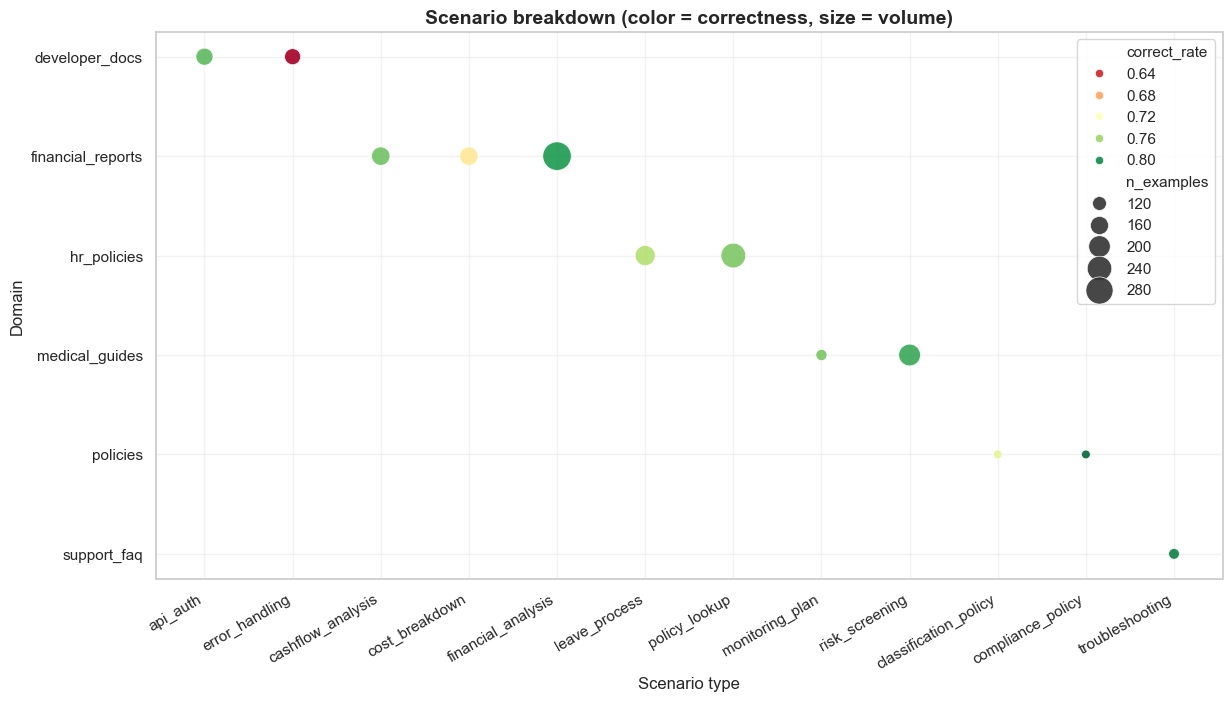

In [ ]:
section("Scenario breakdown", "Find high-volume slices with low correctness (correctness-labeled subset).")

def ensure_numeric_flag_keep_nan(df: pd.DataFrame, col: str) -> None:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "scenarios_" not in globals():
    scenarios_ = scenarios.copy()
    if "difficulty_level" in scenarios_.columns and "difficulty" not in scenarios_.columns:
        scenarios_ = scenarios_.rename(columns={"difficulty_level": "difficulty"})

if "eval_labeled" not in globals():
    eval_labeled = eval_runs.copy()
    ensure_numeric_flag_keep_nan(eval_labeled, "is_correct")
    if "is_correct" in eval_labeled.columns:
        eval_labeled = eval_labeled.dropna(subset=["is_correct"]).copy()

required_cols = {"domain", "scenario_id", "is_correct"}
scenario_cols_ok = {"scenario_id", "scenario_type"}.issubset(scenarios_.columns)

if required_cols.issubset(eval_labeled.columns) and scenario_cols_ok:
    id_col = "example_id" if "example_id" in eval_labeled.columns else ("run_id" if "run_id" in eval_labeled.columns else "scenario_id")

    scen_cols = ["scenario_id", "scenario_type"]
    if "difficulty" in scenarios_.columns:
        scen_cols.append("difficulty")

    runs_scen = eval_labeled.merge(
        scenarios_[scen_cols],
        on="scenario_id",
        how="left",
    )

    if "difficulty" not in runs_scen.columns:
        runs_scen["difficulty"] = "unknown"
    else:
        runs_scen["difficulty"] = runs_scen["difficulty"].fillna("unknown")

    runs_scen["scenario_type"] = runs_scen["scenario_type"].fillna("unknown")
    runs_scen["domain"] = runs_scen["domain"].fillna("unknown")

    risk_slices_tbl = (
        runs_scen
        .groupby(["domain", "scenario_type", "difficulty"], dropna=False)
        .agg(
            correct_rate=("is_correct", "mean"),
            n_examples=(id_col, "size"),
            n_labeled_correct=("is_correct", "count"),
        )
        .reset_index()
    )

    top_types = (
        risk_slices_tbl.groupby("scenario_type")["n_examples"]
        .sum()
        .sort_values(ascending=False)
        .head(12)
        .index
    )

    risk_slices_tbl = risk_slices_tbl[risk_slices_tbl["scenario_type"].isin(top_types)].copy()
    risk_slices_tbl = risk_slices_tbl[risk_slices_tbl["n_examples"] >= MIN_SEGMENT_N].copy()

    if risk_slices_tbl.empty:
        callout("warn", "Scenario breakdown", f"Not enough data after filtering (MIN_SEGMENT_N={MIN_SEGMENT_N}).")
    else:
        display(style_table(
            risk_slices_tbl.sort_values(["correct_rate", "n_examples"]).reset_index(drop=True),
            max_rows=30,
            center_cols=["correct_rate", "n_examples", "n_labeled_correct"],
        ))

        plt.figure(figsize=(12.5, 7.2))
        sns.scatterplot(
            data=risk_slices_tbl,
            x="scenario_type",
            y="domain",
            size="n_examples",
            hue="correct_rate",
            palette="RdYlGn",
            sizes=(40, 420),
            alpha=0.9,
        )
        plt.xticks(rotation=30, ha="right")
        plt.xlabel("Scenario type")
        plt.ylabel("Domain")
        plt.title("Scenario breakdown (color = correctness, size = volume)")
        plt.tight_layout()
        plt.show()

        callout(
            "warn",
            "Priority rule",
            "Start with slices that combine high volume and low correctness, then review hallucination risk within those slices."
        )
else:
    callout("warn", "Scenario breakdown", "Missing required columns or scenario metadata (or no labeled correctness rows).")


retrieval_strategy,generator_model,difficulty,n_rows,n_labeled_correct,correct_rate,n_labeled_hallucination,hallucination_rate,avg_latency_ms,p95_latency_ms,avg_cost_usd,p95_cost_usd,score
bm25_then_rerank,gpt-4o-mini,easy,53,53,0.962264,53,0.000000,685.169811,1055.800000,0.000157,0.000270,0.619632
hybrid,gpt-4o-mini,easy,47,47,0.914894,47,0.042553,655.425532,997.700000,0.000147,0.000276,0.561605
dense_then_rerank,gpt-4o-mini,easy,53,53,0.924528,53,0.037736,687.301887,1041.000000,0.000160,0.000282,0.558188
bm25_then_rerank,llama-3.1-8b-instruct,easy,34,34,0.911765,34,0.058824,785.205882,1346.900000,0.000070,0.000143,0.483847
bm25,gpt-4o-mini,easy,37,37,0.810811,37,0.027027,637.594595,1011.200000,0.000143,0.000272,0.475754
hybrid,gpt-4o,easy,31,31,0.935484,31,0.000000,999.774194,1758.000000,0.001902,0.003778,0.435026
dense,gpt-4o-mini,easy,38,38,0.815789,38,0.105263,668.368421,1082.350000,0.000148,0.000278,0.418403
dense,gpt-4o-mini,medium,173,173,0.809249,173,0.144509,690.849711,1014.800000,0.000153,0.000262,0.377072
bm25,llama-3.1-8b-instruct,easy,31,31,0.806452,31,0.129032,748.774194,1213.000000,0.000065,0.000117,0.354626
bm25_then_rerank,gpt-4o-mini,medium,164,164,0.780488,164,0.189024,663.134146,1023.250000,0.000146,0.000273,0.335462


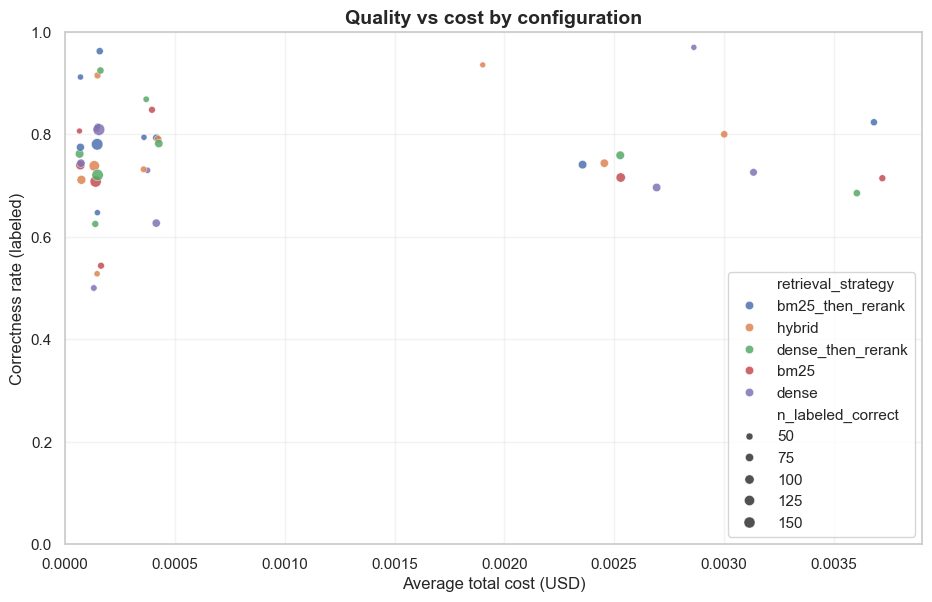

retrieval_strategy,generator_model,difficulty,n_rows,n_labeled_correct,avg_cost_usd,correct_rate
bm25,llama-3.1-8b-instruct,easy,31,31,0.000065,0.806452
bm25_then_rerank,llama-3.1-8b-instruct,easy,34,34,0.000070,0.911765
hybrid,gpt-4o-mini,easy,47,47,0.000147,0.914894
bm25_then_rerank,gpt-4o-mini,easy,53,53,0.000157,0.962264
dense,gpt-4o,easy,33,33,0.002863,0.969697


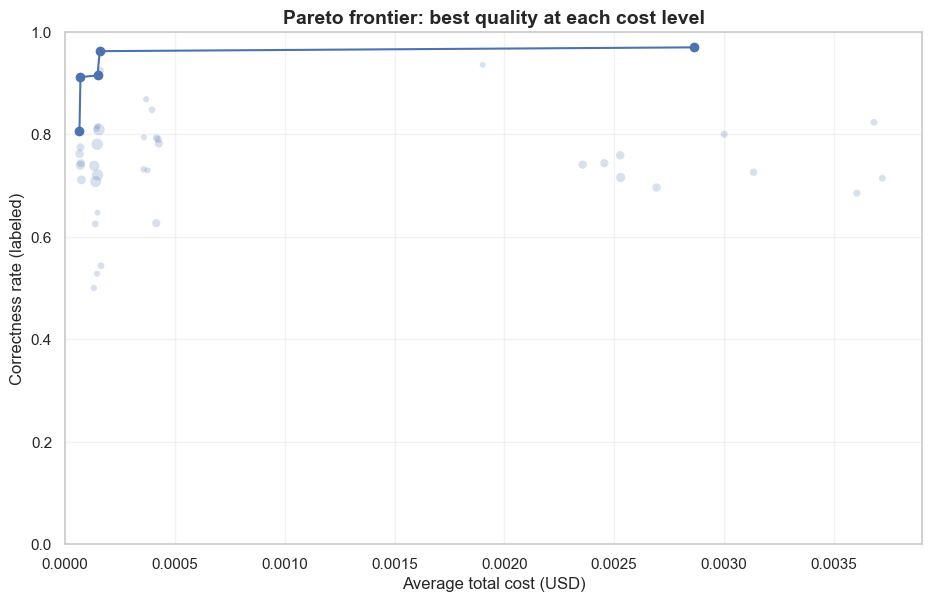

In [ ]:
section("Configuration comparison", "Compare configurations using a blended score (quality, hallucination, latency, cost).")

group_cols = [c for c in ["retrieval_strategy", "generator_model", "difficulty"] if c in eval_runs.columns]

if group_cols:
    config_tbl = summarize_group(eval_runs, group_cols)

    if "n_labeled_correct" in config_tbl.columns:
        config_tbl = config_tbl[config_tbl["n_labeled_correct"] >= MIN_SLICE_N].copy()
    else:
        config_tbl = config_tbl[config_tbl["n_rows"] >= MIN_SLICE_N].copy()

    for c, default in [("hallucination_rate", 0.0), ("avg_latency_ms", 0.0), ("avg_cost_usd", 0.0), ("correct_rate", 0.0)]:
        if c not in config_tbl.columns:
            config_tbl[c] = default

    config_tbl["score"] = (
        config_tbl["correct_rate"].fillna(0.0)
        - 0.6 * config_tbl["hallucination_rate"].fillna(0.0)
        - 0.0005 * config_tbl["avg_latency_ms"].fillna(0.0)
        - 0.30 * config_tbl["avg_cost_usd"].fillna(0.0)
    )

    callout(
        "warn",
        "Heuristic score",
        "This blended score is a simple ranking heuristic (hand-tuned coefficients). Use it for triage, then rely on cost–quality plots and slice sanity checks before making decisions."
    )

    config_tbl = config_tbl.sort_values("score", ascending=False).reset_index(drop=True)
    display(style_table(config_tbl.head(25), max_rows=25))

    if {"avg_cost_usd", "correct_rate"}.issubset(config_tbl.columns):
        plt.figure(figsize=(9.5, 6.2))
        sns.scatterplot(
            data=config_tbl,
            x="avg_cost_usd",
            y="correct_rate",
            hue=group_cols[0],
            size=("n_labeled_correct" if "n_labeled_correct" in config_tbl.columns else "n_rows"),
            alpha=0.85,
        )
        plt.xlabel("Average total cost (USD)")
        plt.ylabel("Correctness rate (labeled)")
        plt.title("Quality vs cost by configuration")
        plt.xlim(left=0)
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()

        frontier = pareto_frontier(config_tbl, x_col="avg_cost_usd", y_col="correct_rate").sort_values("avg_cost_usd")
        show_cols = group_cols + ["n_rows"]
        if "n_labeled_correct" in config_tbl.columns: show_cols += ["n_labeled_correct"]
        show_cols += ["avg_cost_usd", "correct_rate"]
        display(style_table(
            frontier[show_cols].head(20),
            max_rows=20,
            center_cols=[c for c in ["n_rows","n_labeled_correct","avg_cost_usd","correct_rate"] if c in show_cols],
        ))

        plt.figure(figsize=(9.5, 6.2))
        sns.scatterplot(
            data=config_tbl,
            x="avg_cost_usd",
            y="correct_rate",
            size=("n_labeled_correct" if "n_labeled_correct" in config_tbl.columns else "n_rows"),
            alpha=0.22,
            legend=False,
        )
        plt.plot(frontier["avg_cost_usd"], frontier["correct_rate"], marker="o")
        plt.xlabel("Average total cost (USD)")
        plt.ylabel("Correctness rate (labeled)")
        plt.title("Pareto frontier: best quality at each cost level")
        plt.xlim(left=0)
        plt.ylim(0, 1)
        plt.tight_layout()
        plt.show()
else:
    callout("warn", "Configuration comparison", "No strategy columns found; skipping comparison table.")

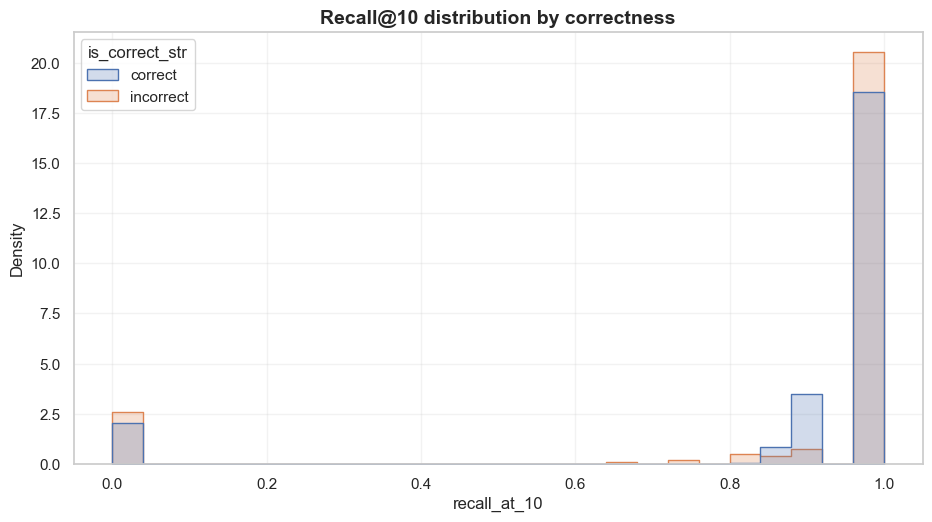

failure_quad,fraction
good_retrieval_good_answer,0.682793
good_retrieval_bad_answer,0.226726
bad_retrieval_good_answer,0.061192
bad_retrieval_bad_answer,0.029289


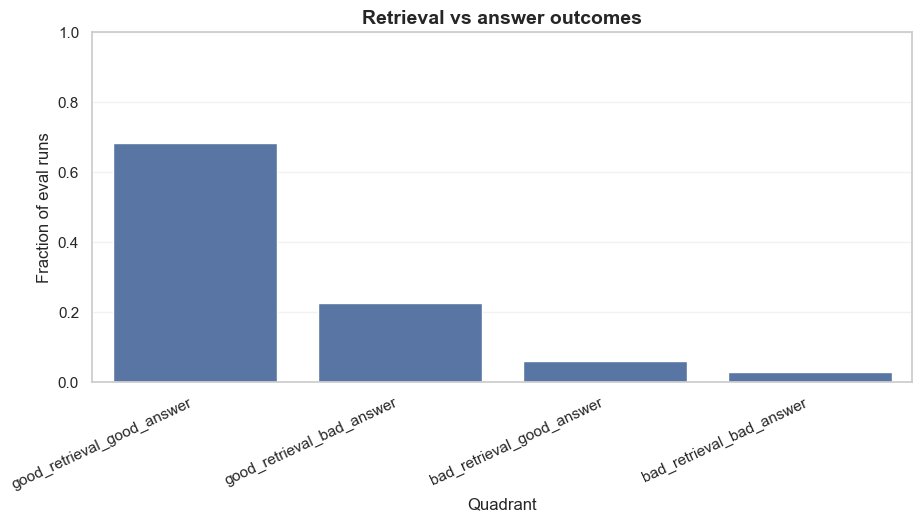

In [24]:
section("Retrieval vs generation", "Separate failure modes using a retrieval quality threshold (correctness-labeled subset).")

source_df = eval_labeled if "eval_labeled" in globals() else eval_runs

if {"recall_at_10", "is_correct"}.issubset(source_df.columns):
    df_r = source_df.copy()
    df_r["is_correct"] = pd.to_numeric(df_r["is_correct"], errors="coerce")
    df_r["recall_at_10"] = pd.to_numeric(df_r["recall_at_10"], errors="coerce")
    df_r = df_r.replace([np.inf, -np.inf], np.nan)

    df_r = df_r.dropna(subset=["is_correct", "recall_at_10"]).copy()
    if df_r.empty:
        callout("warn", "Retrieval vs generation", "Not enough rows with both is_correct and recall_at_10 to compute quadrants.")
    else:
        df_r["is_correct_str"] = df_r["is_correct"].map({0: "incorrect", 1: "correct"}).fillna("unknown")

        plt.figure(figsize=(9.5, 5.4))
        sns.histplot(
            data=df_r,
            x="recall_at_10",
            hue="is_correct_str",
            stat="density",
            common_norm=False,
            bins=25,
            element="step",
        )
        plt.xlabel("recall_at_10")
        plt.title("Recall@10 distribution by correctness")
        plt.tight_layout()
        plt.show()

        callout("warn", "Threshold note", f"RETRIEVAL_OK_THRESHOLD={RETRIEVAL_OK_THRESHOLD:.2f} on recall_at_10 is a design choice. Revisit if your recall definition changes.")

        df_r["retrieval_ok"] = df_r["recall_at_10"] >= RETRIEVAL_OK_THRESHOLD
        df_r["gen_ok"] = df_r["is_correct"] == 1

        def quadrant(row) -> str:
            if row["retrieval_ok"] and row["gen_ok"]:
                return "good_retrieval_good_answer"
            if row["retrieval_ok"] and not row["gen_ok"]:
                return "good_retrieval_bad_answer"
            if (not row["retrieval_ok"]) and row["gen_ok"]:
                return "bad_retrieval_good_answer"
            return "bad_retrieval_bad_answer"

        df_r["failure_quad"] = df_r.apply(quadrant, axis=1)

        quad_stats = (
            df_r["failure_quad"]
            .value_counts(normalize=True)
            .rename("fraction")
            .reset_index()
            .rename(columns={"index": "failure_quad"})
        )
        display(style_table(quad_stats, max_rows=10, center_cols=["fraction"]))

        plt.figure(figsize=(9.5, 5.4))
        sns.barplot(data=quad_stats, x="failure_quad", y="fraction")
        plt.xticks(rotation=25, ha="right")
        plt.ylim(0, 1)
        plt.ylabel("Fraction of eval runs")
        plt.xlabel("Quadrant")
        plt.title("Retrieval vs answer outcomes")
        plt.tight_layout()
        plt.show()

        callout(
            "good",
            "How to use this",
            "Good retrieval + bad answer suggests answer-generation or faithfulness issues. Bad retrieval + bad answer suggests corpus coverage or retriever issues."
        )
else:
    callout("warn", "Retrieval vs generation", "Missing recall_at_10 and/or is_correct.")

model,roc_auc,avg_precision
LogisticRegression,0.754783,0.883068
Random baseline,0.500000,0.743985


Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0      0.822     0.339     0.480       245
           1      0.811     0.975     0.885       711

    accuracy                          0.812       956
   macro avg      0.816     0.657     0.682       956
weighted avg      0.813     0.812     0.781       956



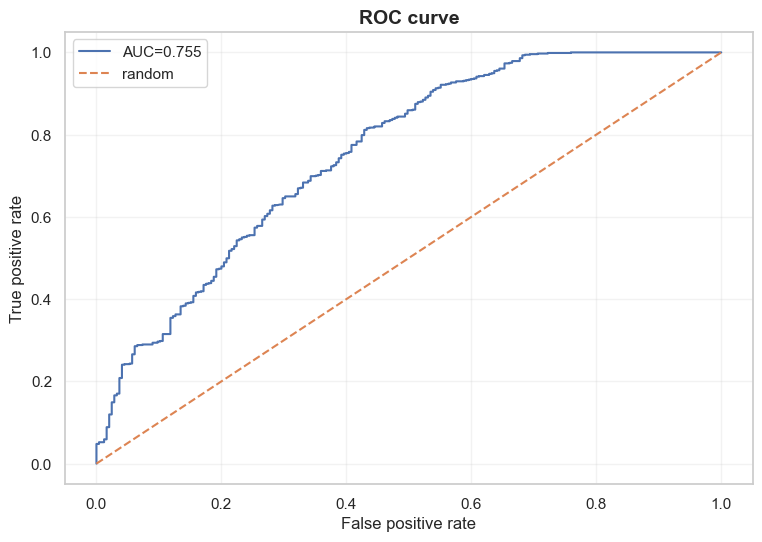

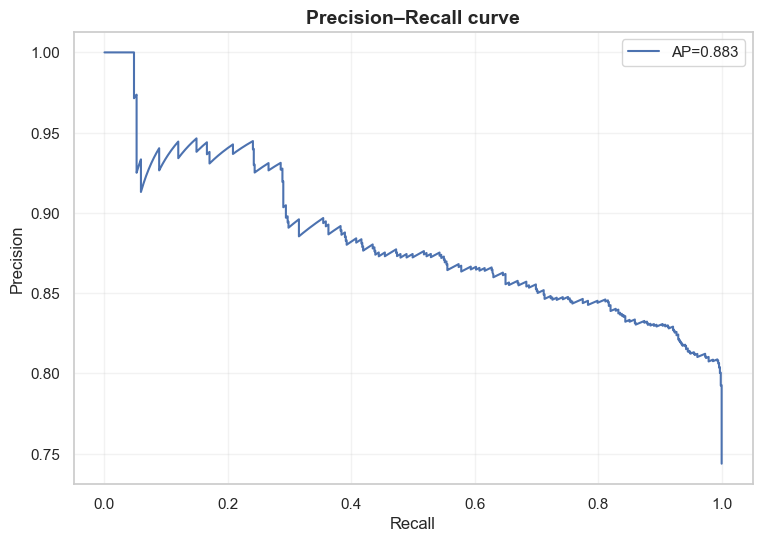

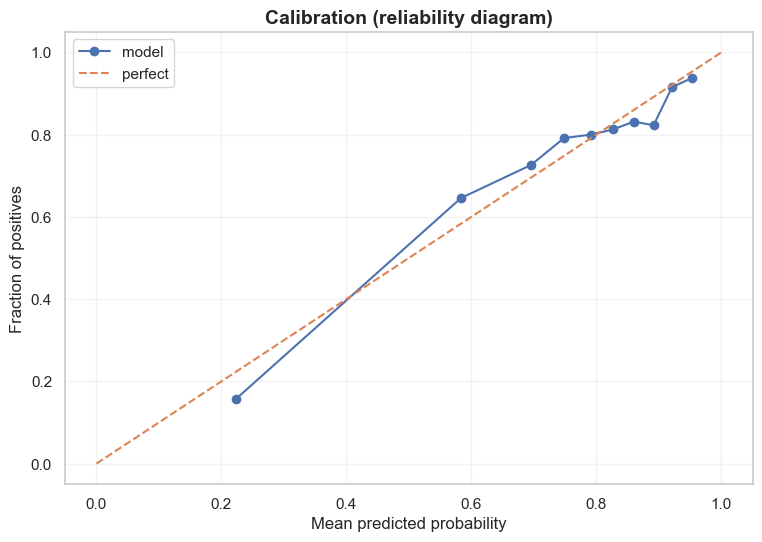

true,pred_0,pred_1
true_0,83,162
true_1,18,693


threshold,coverage,error_rate_on_shown
0.100000,0.973849,0.236305
0.200000,0.945607,0.213496
0.300000,0.932008,0.203143
0.400000,0.915272,0.192000
0.500000,0.894351,0.189474
0.600000,0.843096,0.178660
0.700000,0.743724,0.163150
0.800000,0.525105,0.135458
0.900000,0.223849,0.070093


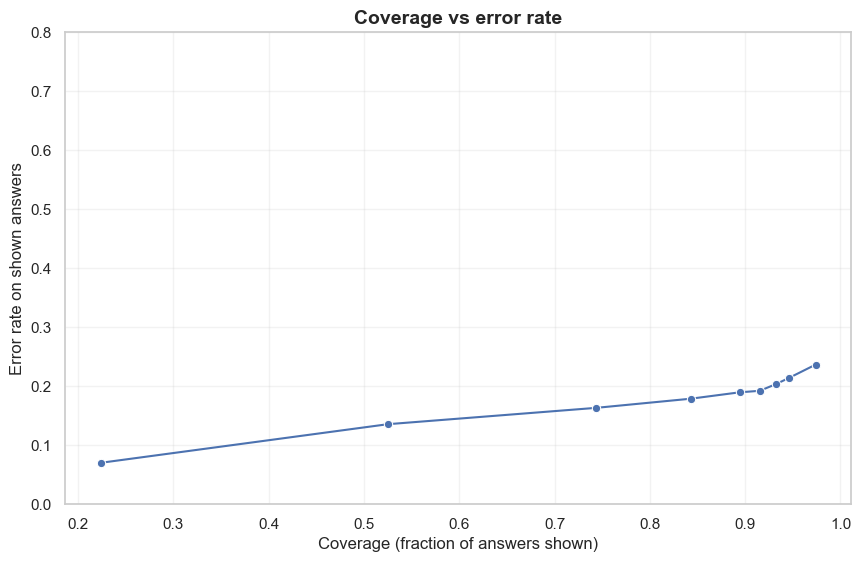

In [ ]:
section("One baseline model", "LogisticRegression baseline + calibration and threshold trade-offs (correctness-labeled subset).")

target_col = "is_correct"

numeric_features = [
    "n_retrieved_chunks","top1_score","mean_retrieved_score","recall_at_5","recall_at_10","mrr_at_10",
    "latency_ms_retrieval","latency_ms_generation","total_latency_ms",
    "context_window_tokens","answer_tokens","prompt_tokens","total_cost_usd",
]
categorical_features = [
    "domain","task_type","difficulty","retrieval_strategy","chunking_strategy",
    "embedding_model","reranker_model","generator_model","eval_mode",
]

source_df = eval_labeled if "eval_labeled" in globals() else eval_runs

feature_cols = [c for c in numeric_features + categorical_features if c in source_df.columns]
meta_df = source_df.copy()
ensure_numeric_flag_keep_nan(meta_df, target_col)
meta_df = meta_df.dropna(subset=[target_col]).copy()

if not feature_cols:
    callout("warn", "Model", "No usable feature columns found for modeling in this file.")
else:
    X = meta_df[feature_cols].copy()

    for c in [c for c in numeric_features if c in X.columns]:
        X[c] = pd.to_numeric(X[c], errors="coerce").replace([np.inf, -np.inf], np.nan)

    y = pd.to_numeric(meta_df[target_col], errors="coerce").astype(int)
    base_rate = float(y.mean()) if len(y) else float("nan")

    callout(
        "good",
        "What the random baseline means",
        "ROC-AUC=0.5 is random guessing. Average Precision (AP) for a random classifier equals the positive-class prevalence (fraction of correct runs). We show it so you can tell if the model learns real signal or just rides class imbalance."
    )

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE,
        stratify=y if y.nunique() > 1 else None,
    )

    num_cols_present = [c for c in numeric_features if c in X.columns]
    cat_cols_present = [c for c in categorical_features if c in X.columns]

    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)

    transformers = []
    if num_cols_present:
        transformers.append((
            "num",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            num_cols_present
        ))
    if cat_cols_present:
        transformers.append((
            "cat",
            Pipeline(steps=[
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", ohe),
            ]),
            cat_cols_present
        ))

    preprocessor = ColumnTransformer(transformers=transformers)

    model = Pipeline(steps=[
        ("prep", preprocessor),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ])

    trained = y_train.nunique() >= 2
    if not trained:
        callout("warn", "Model", "Training split has only one class; skipping LogisticRegression evaluation.")
    else:
        model.fit(X_train, y_train)
        y_proba = model.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= 0.5).astype(int)

        if y_test.nunique() > 1:
            roc_auc = roc_auc_score(y_test, y_proba)
            ap = average_precision_score(y_test, y_proba)

            results_tbl = pd.DataFrame([
                {"model": "LogisticRegression", "roc_auc": roc_auc, "avg_precision": ap},
                {"model": "Random baseline", "roc_auc": 0.5, "avg_precision": base_rate},
            ])
            display(style_table(results_tbl, max_rows=10, center_cols=["roc_auc","avg_precision"]))

            print("Classification report (threshold=0.5):")
            print(classification_report(y_test, y_pred, digits=3))

            fpr, tpr, _ = roc_curve(y_test, y_proba)
            plt.figure(figsize=(7.8, 5.6))
            plt.plot(fpr, tpr, label=f"AUC={roc_auc:.3f}")
            plt.plot([0, 1], [0, 1], "--", label="random")
            plt.xlabel("False positive rate")
            plt.ylabel("True positive rate")
            plt.title("ROC curve")
            plt.legend()
            plt.tight_layout()
            plt.show()

            prec, rec, _ = precision_recall_curve(y_test, y_proba)
            plt.figure(figsize=(7.8, 5.6))
            plt.plot(rec, prec, label=f"AP={ap:.3f}")
            plt.xlabel("Recall")
            plt.ylabel("Precision")
            plt.title("Precision–Recall curve")
            plt.legend()
            plt.tight_layout()
            plt.show()

            frac_pos, mean_pred = calibration_curve(y_test, y_proba, n_bins=10, strategy="quantile")
            plt.figure(figsize=(7.8, 5.6))
            plt.plot(mean_pred, frac_pos, marker="o", label="model")
            plt.plot([0, 1], [0, 1], "--", label="perfect")
            plt.xlabel("Mean predicted probability")
            plt.ylabel("Fraction of positives")
            plt.title("Calibration (reliability diagram)")
            plt.legend()
            plt.tight_layout()
            plt.show()

        cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
        cm_df = pd.DataFrame(cm, index=["true_0", "true_1"], columns=["pred_0", "pred_1"])
        display(style_table(cm_df.reset_index().rename(columns={"index":"true"}), max_rows=10, center_cols=["pred_0","pred_1"]))

        rows = []
        for thr in THRESHOLDS:
            mask_accept = y_proba >= thr
            if mask_accept.sum() == 0:
                coverage = 0.0
                error_rate = np.nan
            else:
                coverage = float(mask_accept.mean())
                shown_correct = float(y_test[mask_accept].mean())
                error_rate = 1.0 - shown_correct
            rows.append({"threshold": float(thr), "coverage": coverage, "error_rate_on_shown": error_rate})

        threshold_tbl = pd.DataFrame(rows)
        display(style_table(threshold_tbl, max_rows=20, center_cols=["threshold","coverage","error_rate_on_shown"]))

        plt.figure(figsize=(8.8, 5.8))
        sns.lineplot(data=threshold_tbl, x="coverage", y="error_rate_on_shown", marker="o")
        plt.xlabel("Coverage (fraction of answers shown)")
        plt.ylabel("Error rate on shown answers")
        plt.title("Coverage vs error rate")
        plt.ylim(0, 0.8)
        plt.tight_layout()
        plt.show()

        callout(
            "good",
            "How to read this",
            f"Random baseline AP is the prevalence (≈ {base_rate:.3f}). If the model is clearly above that baseline, the logs carry usable signal. Calibration tells you whether probabilities are trustworthy for threshold gating."
        )

## Key takeaways

- Use scenario breakdowns to spot high-volume slices with low correctness.
- Use the retrieval-vs-answer view to decide whether to adjust retrieval/corpus or answer generation.
- Use the configuration comparison and cost–quality view to compare settings.
- Use threshold simulation to pick a confidence cutoff that matches your risk tolerance.

## Next steps

- Add interactive filters (domain, scenario_type, difficulty, configuration) for quick drill-down.
- Save slice tables (scenario breakdown, configuration summary, thresholds) as artifacts for a UI layer.
- If you later expand the dataset, re-run the same notebook to track changes over time.
